In [1]:
import numpy as np
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LogNorm
import matplotlib.animation as animation
from matplotlib.patches import ConnectionPatch, Rectangle, FancyArrowPatch
from matplotlib.cm import ScalarMappable

from itertools import product

from numpy import datetime64 as dt
from numpy import timedelta64 as td

import cmocean
import xarray as xr
from glob import glob
import cartopy
from cartopy.crs import Geodetic, PlateCarree, Stereographic
import warnings

import pandas as pd
import geopandas as gpd
import seaborn as sns

warnings.simplefilter("ignore")

# Set Parameters

In [2]:
# Paths
folder_path = "/gxfs_work/geomar/smomw597/2025_copepods/output/"
# trajectory_path = Path(folder_path, f"Trajectories/{year}/")
sample_Points_path = Path(folder_path, "SamplePoints/SamplePoints.shp")
voronoi_Polygons_path = Path(folder_path, "SamplePoints/VoronoiPolygons.shp")
voronoi_Ocean_path = Path(folder_path, "SamplePoints/VoronoiOceanPolygons.shp")
input_path = Path(folder_path, f"VoronoiConnectivity/")

In [3]:
# Load the samplepoints and the voronoi polygons
gdf_sample_points = gpd.read_file(sample_Points_path).to_crs(Geodetic())
gdf_voronoi_polygons = gpd.read_file(voronoi_Polygons_path).to_crs(Geodetic())
gdf_ocean_polygons = gpd.read_file(voronoi_Ocean_path).to_crs(Geodetic())

In [4]:
location_names_sorted = gdf_sample_points.sort_values(by="order").SampleID.tolist()
lons = gdf_sample_points.sort_values(by="order").geometry.x.values
lats = gdf_sample_points.sort_values(by="order").geometry.y.values
n_sites = len(gdf_sample_points)
nondigitalSamples = gdf_sample_points.sort_values(by="order").SampleID.where(gdf_sample_points.SampleKind != 'digital').reset_index().drop(columns='index')
digitalSamples = gdf_sample_points.sort_values(by="order").SampleID.where(gdf_sample_points.SampleKind == 'digital').reset_index().drop(columns='index')
nongeneticSamples = gdf_sample_points.sort_values(by="order").SampleID.where(gdf_sample_points.GenomicDat == False).reset_index().drop(columns='index')
geneticSamples = gdf_sample_points.sort_values(by="order").SampleID.where(gdf_sample_points.GenomicDat == True).reset_index().drop(columns='index')

years = np.arange(2016,2025)
n_years = len(years)

In [5]:
n_days = (np.datetime64("2016-11-01", "D") - np.datetime64("2016-06-01", "D")).astype("int")
n_timesteps_day = 24*4
n_days_life = 28
n_days_adult = 18
n_particles = 1000
# Check wether n_timesteps_day is needed oreven wrong here
n_total = n_days * n_years * n_timesteps_day * n_days_life * n_sites * n_particles
n30d = 30 * n_years * n_timesteps_day * n_days_life * n_sites * n_particles
n31d = 31 * n_years * n_timesteps_day * n_days_life * n_sites * n_particles

total_particle_count_per_site = n_days * n_years * n_particles
max_observation_single_particle = n_days_adult * n_timesteps_day

In [6]:
# Set the basic mapping parameters
suptitle_size = 20
title_size = 16
axis_size = 16
mapsize = (16, 8)
extent = (2.5, 27.5, 52, 62)
lonmid = np.mean(extent[:2])
latmid = np.mean(extent[2:])
map_projection = Stereographic(
    central_longitude=lonmid, central_latitude=latmid,
    )
def basemap(ax):
    ax.set_extent(extent, PlateCarree())
    ax.add_feature(LAND)
    ax.add_feature(COASTLINE)
    ax.gridlines(draw_labels=["left", "bottom"], y_inline=False,)
    return ax

In [7]:
# input_path = Path("/gxfs_work/geomar/smomw597/2025_copepods/output/")
figure_outpath = Path("/gxfs_work/geomar/smomw597/2025_copepods/Figures/")

# Functions

In [8]:
def sort_cmatrix(matrix_in):
    matrix = matrix_in[location_names_sorted + [c for c in matrix_in.columns if c not in location_names_sorted]]
    return matrix.reindex(location_names_sorted)

In [9]:
def map_sites(ax):
    return ax.scatter(
        lons, lats,
        transform=Geodetic(),
        c="magenta", s=25,
    )

In [10]:
def basemap(ax):
    ax.set_extent(extent, PlateCarree())
    ax.add_feature(cartopy.feature.LAND)
    ax.add_feature(cartopy.feature.COASTLINE)
    ax.gridlines(draw_labels=["left", "bottom"], y_inline=False,)
    return ax

In [11]:
def make_cbar(fig, ax, hist):
    cax = fig.add_axes(
        [
            ax.get_position().x1+0.01,
            ax.get_position().y0, 0.02,
            ax.get_position().height
        ]
    )
    return plt.colorbar(hist, cax=cax,)

In [12]:
def highlight_single_cell(ax, idx):
        return ax.add_patch(Rectangle((idx, idx),1,1, fill=False, edgecolor='k', lw=1, zorder=3))

def highlight_col(ax, idx, length):
        # ax.add_patch(Rectangle((idx, 0),1,length, fill=False, edgecolor='red', lw=1, zorder=1))
        return ax.add_patch(Rectangle((idx, 0),1,length, fill=True, color='lightgray', edgecolor='red', lw=1, alpha=0.3, zorder=0))
def highlight_row(ax, idx, length):
        return ax.add_patch(Rectangle((0, idx),length,1, fill=True, color='lightgray', lw=0.5, alpha=0.3, zorder=0))
        # return ax.add_patch(Rectangle((0, idx),length,1, fill=False, edgecolor='lightgray', lw=1, zorder=1))

def draw_guides(ax):
        length = len(df_cmatrix_total.index)
        geneticSamples_list = nongeneticSamples.dropna().values.T[0]
        for idx, site_name in enumerate(df_cmatrix_total.index):
                if site_name not in geneticSamples_list:
                        highlight_col(ax, idx, length)
                        highlight_row(ax, idx, length)
        return ax

In [66]:
def define_cmap(cmap_input='coolwarm', cmdiscrete=False, value_min=None, value_max=None):
        if isinstance(cmap_input, str):
                cmap = mpl.colormaps.get_cmap(cmap_input)
        elif isinstance(cmap_input, type(cmocean.cm.haline)):
                cmap = cmap_input
        elif not isinstance(cmap_input, type(cmocean.cm.haline)):
                return print("Please input colormap or colormap name (str).")

        vmax = 10**np.ceil(np.log10(value_max))
        vmin = 10**np.floor(np.log10(value_min))
        sample_steps = vmax-vmin
        bounds = np.arange(vmin, vmax+1)
        fmt = ".0f"
        norm = mpl.colors.Normalize(vmin=value_min, vmax=value_max)
        # resample the colormap into the amount of discrete steps of difference between the vmin and vmax in power of 10
        steps = (np.log10(vmax) - np.log10(vmin)).astype(int) 
        if steps >2:
                sample_steps = steps
                bounds = np.logspace(np.log10(vmin), np.log10(vmax), steps+1)
                fmt = ".0e"
                norm = LogNorm(vmin=vmin, vmax=vmax,)
        else:
                sample_steps = value_max-value_min
        if cmdiscrete:
                cmap = cmap.resampled(sample_steps)
                cmap.set_under(color="#00000000") # force the first color entry to be invisible
        return cmap, bounds, fmt, norm

In [77]:
def build_ax(ax, fontsize=10, labelpad=15, xlabelposition="top", highlight_genetic=False,):
        ax.xaxis.set_label_position(xlabelposition)  
        # ax.set_yticklabels(ax.get_yticklabels(), rotation=90)
        pad = 5
        if xlabelposition == "top":
                ax.tick_params(
                        grid_linewidth=0, labelsize=fontsize, 
                        labelbottom=False, labeltop=True, 
                        size=0, pad=pad,
                        )
        if highlight_genetic:
                pad = 2
                for x_tick, y_tick in zip(ax.get_xticklabels(), ax.get_yticklabels()):
                        if x_tick.get_text() not in nongeneticSamples.dropna().values.T[0]:
                                x_tick.set_fontweight("bold")
                                y_tick.set_fontweight("bold")
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0,)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90,)
        ax.set_ylabel("Source Stations", size=fontsize, labelpad=labelpad)
        ax.set_xlabel("Target Stations", size=fontsize, labelpad=labelpad)
        return ax

def drop_nongenetic(matrix):
        geneticSamples_list = nongeneticSamples.dropna().values.T[0]
        return matrix.drop(columns=geneticSamples_list, index=geneticSamples_list)

def drop_digital(matrix):
        digitalSamples_list = digitalSamples.dropna().values.T[0]
        return matrix.drop(columns=digitalSamples_list, index=digitalSamples_list)

def showConnectivityMatrix(matrix, fn = None, vmin = None, vmax = None, only_genetic=True, only_real=False, cmap="coolwarm",
        highlight_genetic=False, title="Connectivity Matrix",
        cbtitle=None, cmdiscrete=False, fontsize=10, titlesize=12, annot=True, fmt = ".0e",
        draw_cbar=True, figsize=(7, 7), filename=None):

        if only_genetic:
                matrix = drop_nongenetic(matrix)
        if only_real:
                matrix = drop_digital(matrix)
        value_max = matrix.max(axis=None)
        value_min = matrix.where(matrix != 0).min(axis=None)
        
        cmap, bounds, fmt, norm = define_cmap(cmdiscrete=cmdiscrete, value_max=value_max, value_min=value_min, cmap_input=cmap)
        cbar_format = "%"+fmt
        mask = matrix == 0
        cbar_kws = dict(label=cbtitle, norm=norm, format=cbar_format, ticks=bounds,)
        if draw_cbar:
                fig, (ax, cbar_ax) = plt.subplots(nrows=1, ncols=2, figsize=(8, 7), gridspec_kw={"width_ratios":(0.9, 0.05),},)
        else:
                fig, ax = plt.subplots(nrows=1, ncols=1, figsize=figsize)
                cbar_ax = ax
        fig.suptitle(title, size=titlesize)
        sns.heatmap(
                matrix, mask=mask, cmap=cmap, ax=ax, 
                linewidths=0.5, linecolor="lightgrey",
                norm=norm, square=True,
                annot=annot, fmt=fmt, annot_kws={"size": fontsize},
                cbar=draw_cbar, cbar_kws=cbar_kws, cbar_ax=cbar_ax,
        )
        if draw_cbar:
                cbar_ax.minorticks_off()
        if not only_genetic and not only_real:
                ax = draw_guides(ax)
        ax = build_ax(ax, fontsize=fontsize, highlight_genetic=highlight_genetic)
        plt.tight_layout()
        if filename is not None:
                plt.savefig(Path(figure_outpath, filename), format="pdf")
        return plt.show()

# Connectivity Matrices

In [15]:
connectivity_matrix_voronoi_list = sorted(input_path.glob(f'*'))
print(len(connectivity_matrix_voronoi_list))

for i, matrix_link in enumerate(connectivity_matrix_voronoi_list): 
    if i == 0:
        connectivity_matrix = pd.read_csv(connectivity_matrix_voronoi_list[0], index_col=0)
    else:
        connectivity_matrix = connectivity_matrix + pd.read_csv(connectivity_matrix_voronoi_list[0], index_col=0)

9


In [16]:
new_index_mapper = dict(zip(gdf_sample_points.SampleID_o.values, gdf_sample_points.SampleID.values))
connectivity_matrix = connectivity_matrix.rename(columns=new_index_mapper, index=new_index_mapper)

In [17]:
df_cmatrix_total = sort_cmatrix(connectivity_matrix)
df_cmatrix_normalized = df_cmatrix_total.copy()

df_cmatrix_relative = df_cmatrix_total.copy()/(max_observation_single_particle * total_particle_count_per_site)

for i, column in enumerate(df_cmatrix_total.columns):
    area = gdf_ocean_polygons.loc[i,'area']
    count = df_cmatrix_total.loc[:,column]
    normalized_count = (count/area)*25
    df_cmatrix_normalized.loc[:,column] = normalized_count
df_cmatrix_normalized_relative = df_cmatrix_normalized.copy()/(max_observation_single_particle * total_particle_count_per_site)

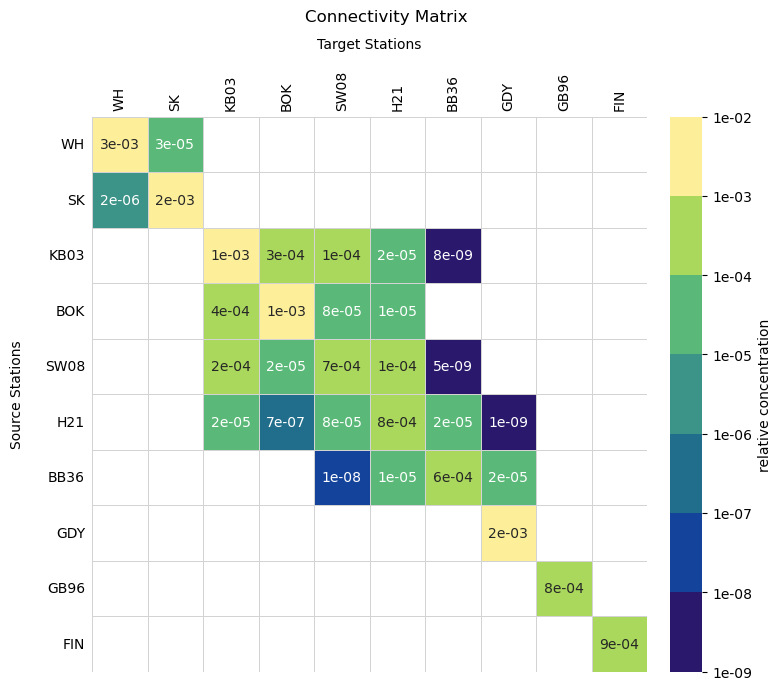

In [78]:
# colorbar title relative concentration
showConnectivityMatrix(
        df_cmatrix_normalized_relative, only_genetic=True, cbtitle="relative concentration",
        cmdiscrete=True, annot=True, cmap=cmocean.cm.haline,
        filename="Connectivity_matrix_genetic.pdf"
)

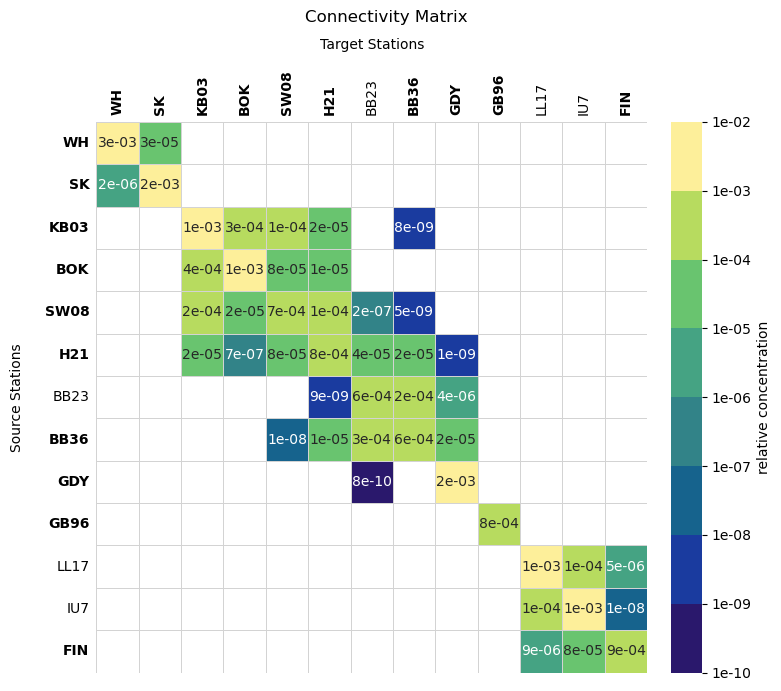

In [79]:
# colorbar title relative concentration
showConnectivityMatrix(
        df_cmatrix_normalized_relative, only_genetic=False, only_real=True, cbtitle="relative concentration",
        cmdiscrete=True, annot=True, cmap=cmocean.cm.haline, highlight_genetic=True,
        filename="Connectivity_matrix_real.pdf"
)

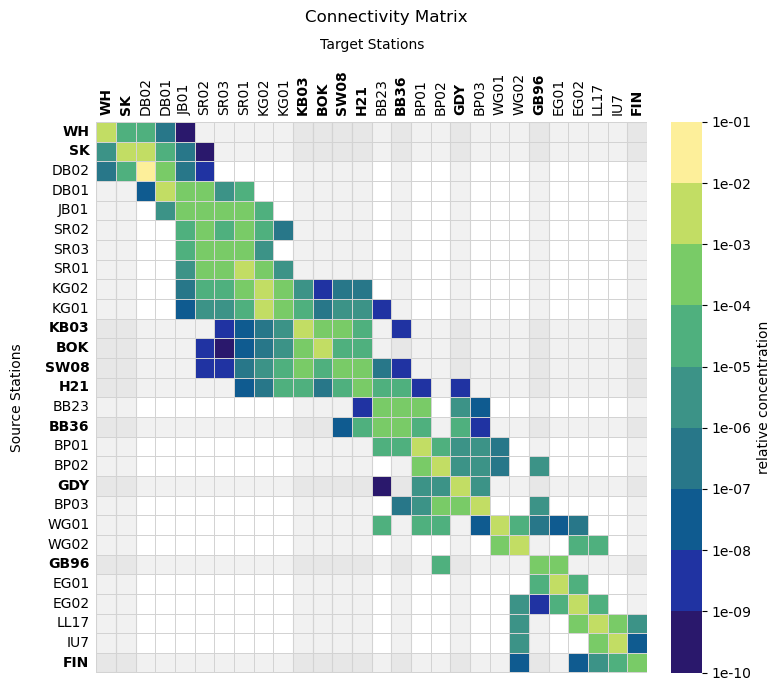

In [81]:
# colorbar title relative concentration
showConnectivityMatrix(
        df_cmatrix_normalized_relative, only_genetic=False, cbtitle="relative concentration",
        cmdiscrete=True, annot=False, cmap=cmocean.cm.haline, highlight_genetic=True,
        filename="Connectivity_matrix_all.pdf"
)

In [82]:
generation_matrix = pd.DataFrame(0, columns=df_cmatrix_normalized_relative.columns, index=df_cmatrix_normalized_relative.index)
for i in np.arange(25):
    if i == 0:
        generation_connectivity_matrix = df_cmatrix_normalized_relative.copy()
        generation_matrix = df_cmatrix_normalized_relative.where(generation_connectivity_matrix==0, i+1)
    else:
        generation_connectivity_matrix = df_cmatrix_normalized_relative.dot(generation_connectivity_matrix)
        generation_matrix = generation_matrix.where((generation_matrix[generation_matrix == 0].isnull()) | (generation_connectivity_matrix==0), i+1)
    if generation_matrix.min(axis=None) > 0:
        break

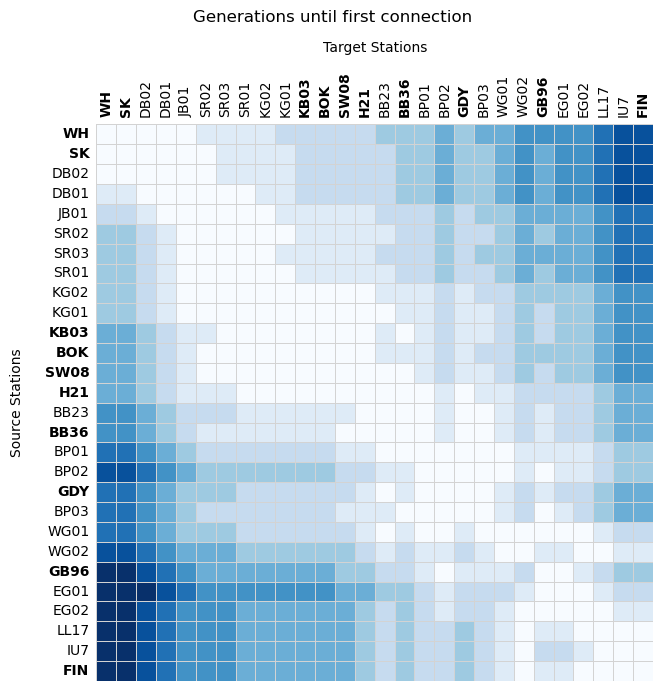

In [ ]:
# colorbar title relative concentration
showConnectivityMatrix(
        generation_matrix, only_genetic=False, cbtitle="Generations until connected",
        cmdiscrete=True, cmap="Blues", draw_cbar=False, annot=False, highlight_genetic=True,
        title="Generations until first connection",
        filename="generation_matrix_all.pdf"
        )

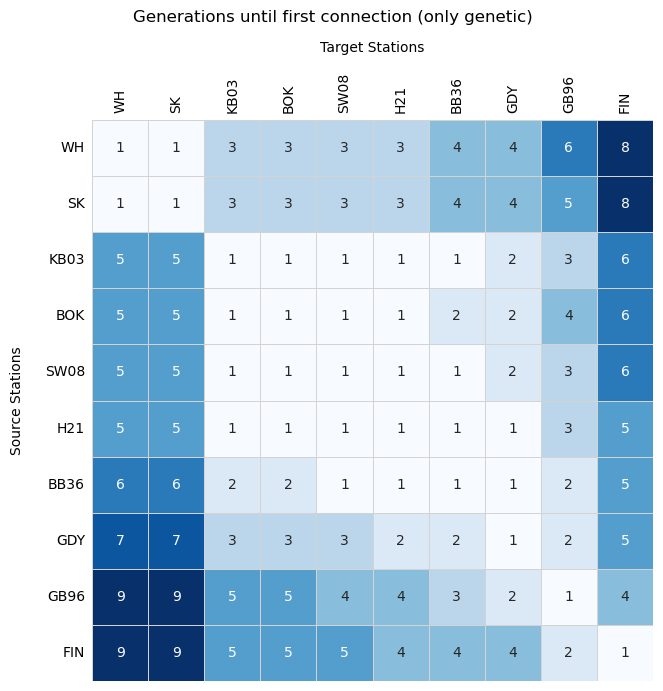

In [85]:
# colorbar title relative concentration
showConnectivityMatrix(
        generation_matrix, only_genetic=True, cbtitle="Generations until connected",
        cmdiscrete=True, cmap="Blues", draw_cbar=False, annot=True,
        title="Generations until first connection (only genetic)",
        filename="generation_matrix_genetic.pdf"
        )

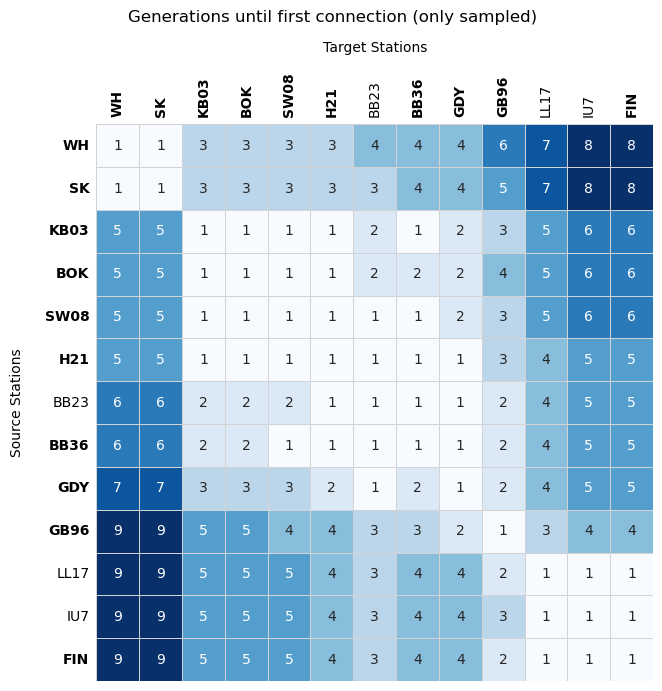

In [86]:
# colorbar title relative concentration
showConnectivityMatrix(
        generation_matrix, only_genetic=False, only_real=True, cbtitle="Generations until connected",
        cmdiscrete=True, cmap="Blues", draw_cbar=False, annot=True, highlight_genetic=True,
        title="Generations until first connection (only sampled)",
        filename="generation_matrix_real.pdf"
        )

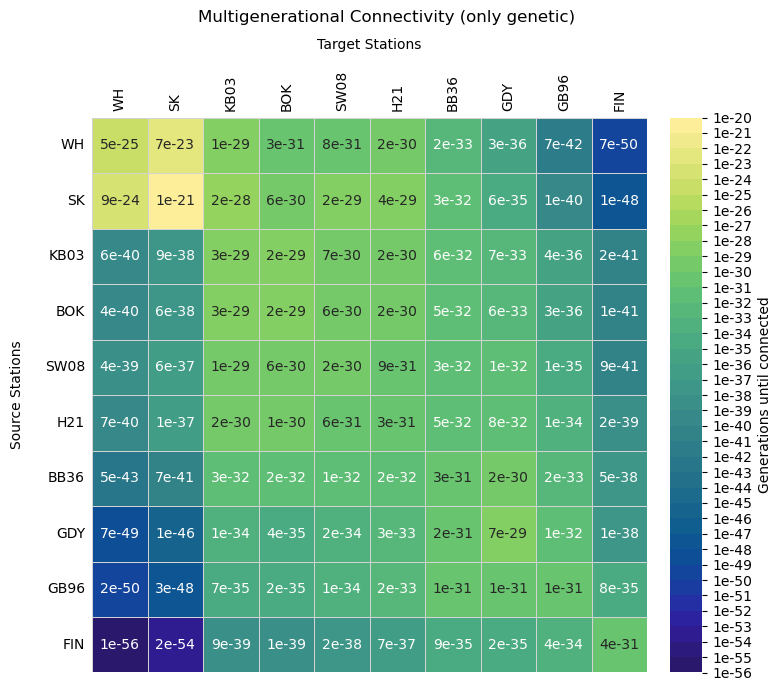

In [93]:
# colorbar title relative concentration
showConnectivityMatrix(
        generation_connectivity_matrix, only_genetic=True, cbtitle="Generations until connected",
        cmdiscrete=True, cmap=cmocean.cm.haline, draw_cbar=True, annot=True,
        title="Multigenerational Connectivity (only genetic)",
        filename="generational_connectivity_matrix_genetic.pdf"
        )

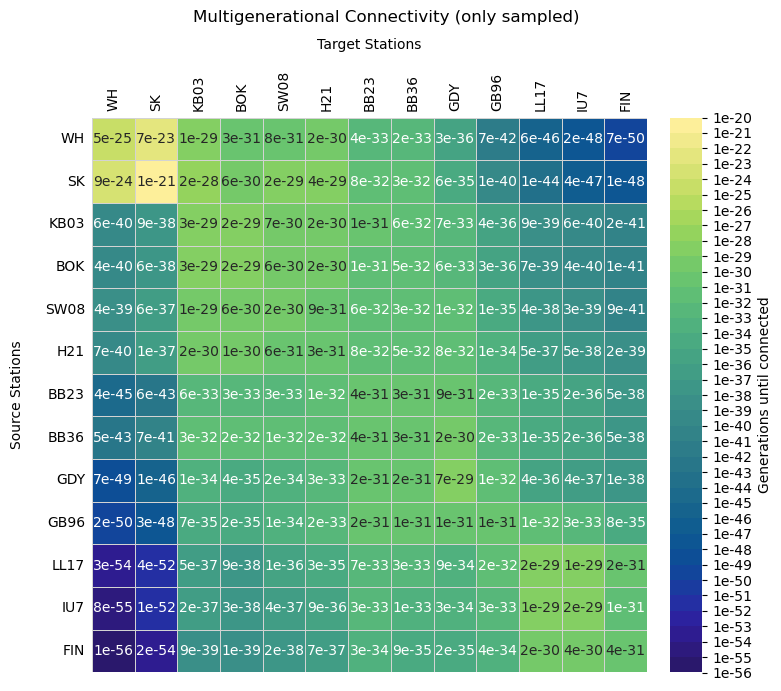

In [94]:
# colorbar title relative concentration
showConnectivityMatrix(
        generation_connectivity_matrix, only_genetic=False, only_real=True, cbtitle="Generations until connected",
        cmdiscrete=True, cmap=cmocean.cm.haline, draw_cbar=True, annot=True,
        title="Multigenerational Connectivity (only sampled)",
        filename="generational_connectivity_matrix_real.pdf"
        )

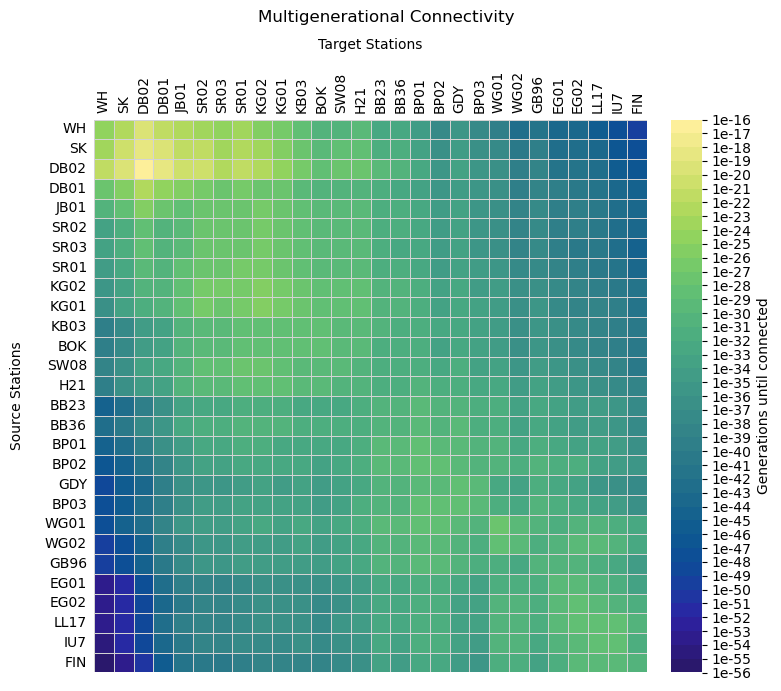

In [90]:
# colorbar title relative concentration
showConnectivityMatrix(
        generation_connectivity_matrix, only_genetic=False, cbtitle="Generations until connected",
        cmdiscrete=True, cmap=cmocean.cm.haline, draw_cbar=True, annot=False,
        title="Multigenerational Connectivity",
        filename="generational_connectivity_matrix_all.pdf"
        )

# Maps

In [84]:
sample_points = gdf_sample_points.copy().to_crs(map_projection)
voronoi_polys = gdf_voronoi_polygons.copy().to_crs(map_projection)

def draw_voronoi_polygons(ax, cmap="rainbow", edgecolor="black", facealpha=0.2):
        voronoi_polys = gdf_voronoi_polygons.copy().to_crs(map_projection)
        voronoi_polys.plot(ax=ax, alpha=facealpha, column="PolygonID", cmap=cmap)
        voronoi_polys.boundary.plot(ax=ax, color=edgecolor,)

def legend_without_duplicate_labels(ax):
    handles, labels = ax.get_legend_handles_labels()
    unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
    ax.legend(*zip(*unique))

markers = pd.DataFrame(
    data=np.array([["darkred", "o",],["dodgerblue", "^"], ["salmon", "s"]]),
    index=["real", "digital", "moved"], 
    columns=["color", "marker"],
    )



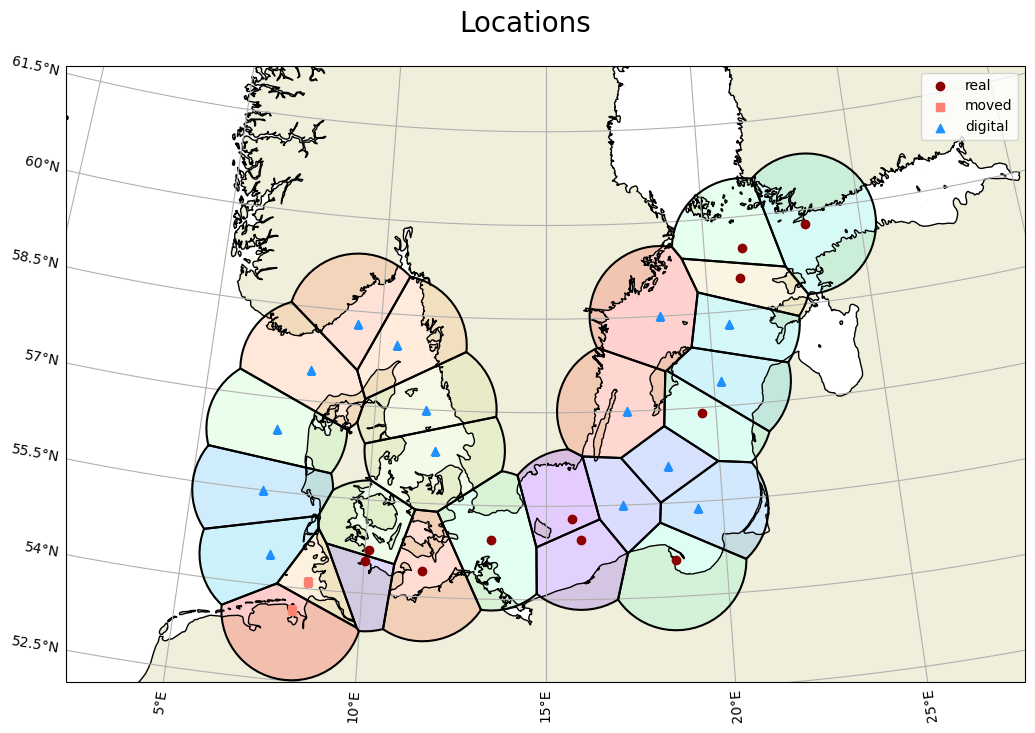

In [89]:
show_polygons = True

fig = plt.figure(figsize=mapsize)
fig.suptitle("Locations", size=suptitle_size, y=0.95)
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
if show_polygons:
        draw_voronoi_polygons(ax_map)

for index, (name, sampleID, sampleID_old, kind, genomicData, order, geometry) in sample_points.iterrows():
        lon, lat = geometry.x, geometry.y
        marker = markers["marker"][kind]
        color = markers["color"][kind]
        ax_map.scatter(lon, lat, marker=marker, color=color, zorder=5, label=kind)

legend_without_duplicate_labels(ax_map)

# plt.savefig(Path(figure_outpath, "EmptyMap.pdf"), format="pdf")
plt.show()

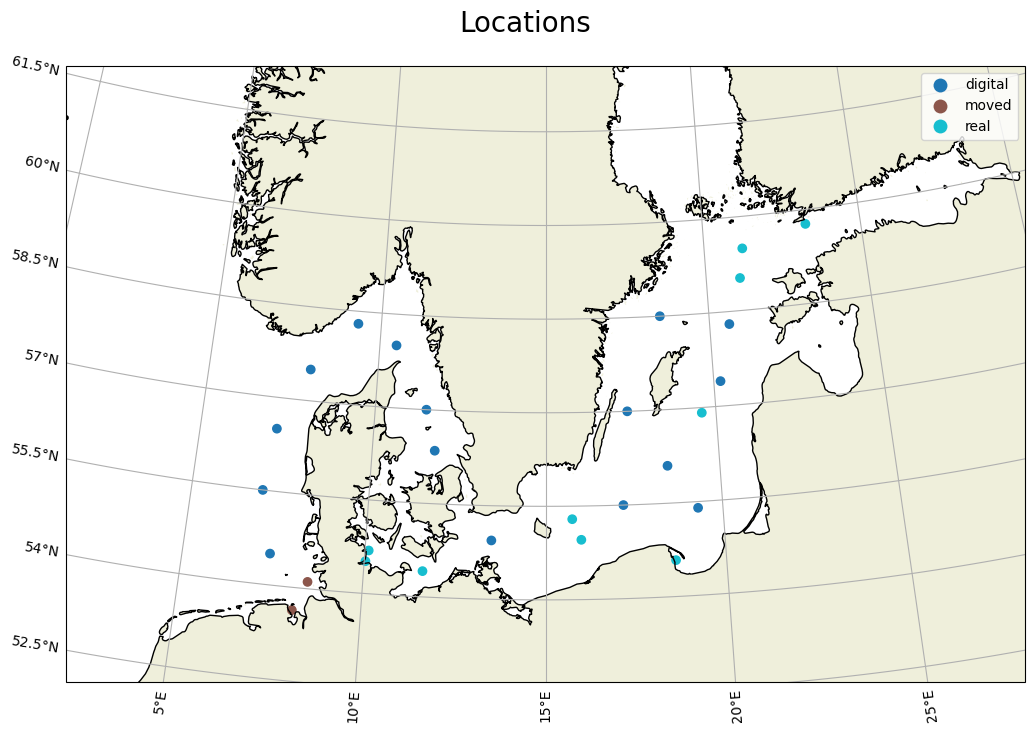

In [ ]:
fig = plt.figure(figsize=mapsize)
fig.suptitle("Locations", size=suptitle_size, y=0.95)
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
# Add the red dots for the non sampled points
gdf_sample_points.to_crs(map_projection).plot(ax=ax_map,column="SampleKind", legend=True)
# plt.savefig(Path(figure_outpath, "EmptyMap.png"), format="png")
plt.show()

## Connectivity Map

In [48]:
def read_cmap(cmap_input):
        if isinstance(cmap_input, str):
                return mpl.colormaps.get_cmap(cmap_input)
        elif isinstance(cmap_input, type(cmocean.cm.haline)):
                return cmap_input
        elif not isinstance(cmap_input, type(cmocean.cm.haline)):
                return print("Please input colormap or colormap name (str).")

def draw_connections(fig, ax, matrix, 
        cmap_scatter=cmocean.cm.matter, cmap_arrows = cmocean.cm.haline,
        norm=None):
        sample_points = gdf_sample_points.copy().sort_values(by="order").to_crs(map_projection)
        min_connection, max_connection = matrix.min(axis=None), matrix.max(axis=None)
        for (incomming, outgoing) in product(matrix, repeat=2):
                n_connections = matrix[outgoing][incomming]
                if np.isnan(n_connections):
                        continue # don't draw if there are noe connections
                
                geom_outgoing = sample_points[sample_points.SampleID == outgoing].geometry
                xy_outgoing = getXY(geom_outgoing)
                con_size = (n_connections/max_connection)
                if outgoing == incomming:
                        color_scatter = cmap_scatter(norm(n_connections),)
                        geom_outgoing.plot(ax=ax, color=color_scatter, markersize=con_size*500, zorder=2,)
                        continue
                
                geom_incomming = sample_points[sample_points.SampleID == incomming].geometry
                xy_incomming = getXY(geom_incomming)

                incomming_in_extent = ax.get_extent()[0] < xy_incomming[0] < ax.get_extent()[1]
                outgoing_in_extent = ax.get_extent()[0] < xy_outgoing[0] < ax.get_extent()[1]
                if incomming_in_extent and outgoing_in_extent:
                        con_alpha = (n_connections/max_connection)**(1/60)
                        con_lw = (n_connections/max_connection)**(1/15)
                        color_arrow = cmap_arrows(norm(n_connections))

                        con = ConnectionPatch(
                                xyA=xy_outgoing, xyB=xy_incomming, coordsA=ax.transData,
                                color=color_arrow, lw=con_lw*4, alpha=con_alpha, zorder=5
                        )
                        con.set_arrowstyle("-|>,head_length=0.4,widthB=1")
                        con.set_connectionstyle("Arc3,rad=0.2")
                        ax.add_artist(con)

def getXY(pt):
    return (pt.x.values[0], pt.y.values[0])

def extent_to_rectangle(extent):
    x, y = extent[0], extent[2]
    width = extent[1] - extent[0]
    height = extent[3] - extent[2]
    return (x, y), width, height

def draw_self_connections(ax, matrix, norm, cmap=cmocean.cm.matter):
        sample_points = gdf_sample_points.copy().set_index("SampleID").to_crs(map_projection)
        sample_points = sample_points[sample_points["SampleKind"] != "digital"]
        
        min_connection, max_connection = matrix.min(axis=None), matrix.max(axis=None)

        self_connections = [[i, matrix[i][i]] for i in matrix.index]
        self_connections = pd.DataFrame(data=self_connections, columns=["SampleID","self_connection"]).set_index("SampleID")

        sample_points = sample_points.join(self_connections)
        
        colors = [cmap(norm(self_connection),) for self_connection in sample_points.self_connection]
        sizes = [100 + (self_connection/max_connection)*500 for self_connection in sample_points.self_connection]
        sample_points.plot(ax=ax, color=colors, markersize=sizes, edgecolor="k",)



In [49]:
def draw_connections(ax, matrix, norm, cmap = cmocean.cm.haline,):
        sample_points = gdf_sample_points.copy().sort_values(by="order").to_crs(map_projection)
        min_connection, max_connection = minmax_not_diagonal(matrix)
        for (incomming, outgoing) in product(matrix, repeat=2):
                n_connections = matrix[outgoing][incomming]
                if np.isnan(n_connections):
                        continue # don't draw if there are noe connections
                
                geom_outgoing = sample_points[sample_points.SampleID == outgoing].geometry
                xy_outgoing = getXY(geom_outgoing)
                
                geom_incomming = sample_points[sample_points.SampleID == incomming].geometry
                xy_incomming = getXY(geom_incomming)

                incomming_in_extent = ax.get_extent()[0] < xy_incomming[0] < ax.get_extent()[1]
                outgoing_in_extent = ax.get_extent()[0] < xy_outgoing[0] < ax.get_extent()[1]

                if not incomming_in_extent or not outgoing_in_extent:
                        continue

                color = cmap(norm(n_connections))
                con = ConnectionPatch(
                        xyA=xy_outgoing, xyB=xy_incomming, coordsA=ax.transData,
                        color=color, lw=2.2, zorder=5, edgecolor="k",
                        shrinkA=10, shrinkB=10,
                )
                con.set_arrowstyle("-|>,head_length=0.4,widthB=1")
                con.set_connectionstyle("Arc3,rad=0.3")
                ax.add_artist(con)

In [50]:
def minmax_not_diagonal(matrix):
        np.fill_diagonal(matrix.copy().values, 0)
        zero_mask = (matrix == 0)
        matrix = matrix.mask(zero_mask)
        return matrix.min(axis=None), matrix.max(axis=None)    

In [51]:
def draw_connectivitymap(matrix, ax_pos, cmap_arrows, extent=None, projection=map_projection):
        ax = fig.add_axes(ax_pos, projection=projection)
        basemap(ax)
        if extent is not None:
                ax.set_extent(extent, PlateCarree())
        draw_connections(ax, matrix, cmap=cmap_arrows)
        draw_self_connections(ax, matrix, cmap=cmap_arrows)
        return ax

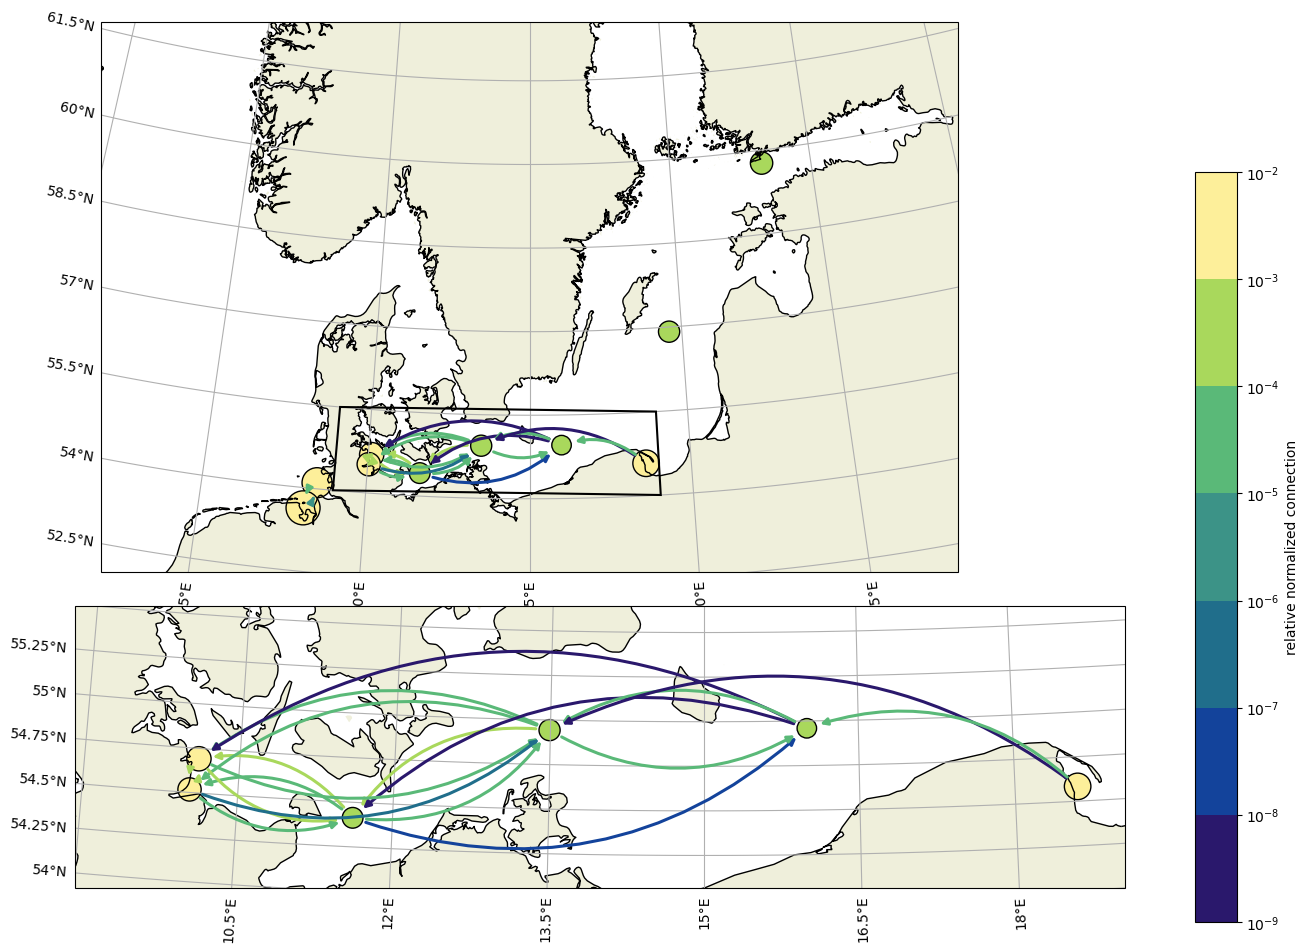

In [64]:
def make_connectivitymap(
        matrix, 
        map_projection=map_projection, mapsize=mapsize, suptitle="Connectivity Map",
        only_genetic=True, show_polygons=False, 
        cmap_scatter=cmocean.cm.matter, cmap = cmocean.cm.haline,
        filename=None,
        ):
        matrix = matrix.mask(matrix == 0)
        matrix = drop_nongenetic(matrix, only_genetic)
        sample_points = gdf_sample_points.copy().sort_values(by="order").to_crs(map_projection)
        voronoi_polys = gdf_voronoi_polygons.copy().to_crs(map_projection)

        if only_genetic:
                voronoi_polys = voronoi_polys[voronoi_polys['SampleKind'] != 'digital']
                sample_points = sample_points[sample_points["SampleKind"] != "digital"]
        if show_polygons:
                draw_voronoi_polygons(ax=ax_main)
        
        min_connection, max_connection = matrix.min(axis=None), matrix.max(axis=None)
        cmap = read_cmap(cmap)
        (cmap, bounds_arrows, fmt, norm) = define_cmap(cmap, cmdiscrete=True, value_min=min_connection, value_max=max_connection)
        
        fig = plt.figure(figsize=(14,10))

        # Main Map in top left
        ax_main = fig.add_axes([0.05, 0.4, 0.65, 0.55], projection=map_projection)
        basemap(ax_main)
        draw_connections(ax_main, matrix, norm=norm, cmap=cmap)
        scatter = draw_self_connections(ax_main, matrix, norm=norm, cmap=cmap)
        
        # Zoom onto west baltic in bottom left
        ax_westbaltic = fig.add_axes([0.05, 0.05, 0.75, 0.35], projection=map_projection)
        basemap(ax_westbaltic)
        westbaltic_extent = [9,19,54,55.5,]
        ax_westbaltic.set_extent(westbaltic_extent, PlateCarree())
        draw_connections(ax_westbaltic, matrix, norm=norm, cmap=cmap)
        draw_self_connections(ax_westbaltic, matrix, norm=norm, cmap=cmap)

        cax_arrows = fig.add_axes([0.85, 0.05, 0.03, 0.75])
        fig.colorbar(ScalarMappable(norm, cmap), cax=cax_arrows, label="relative normalized connection")
        cax_arrows.minorticks_off()

        westbaltic_xy, westbaltic_width, westbaltic_height = extent_to_rectangle(westbaltic_extent)
        ax_main.add_patch(Rectangle(
                westbaltic_xy, westbaltic_width, westbaltic_height,
                fill=False, color='k', lw=1.5, zorder=100, transform=Geodetic(),
        ))

        if filename is not None:
                plt.savefig(Path(figure_outpath, filename), format="pdf")
        plt.show()

matrix=df_cmatrix_normalized_relative.copy()
make_connectivitymap(matrix=matrix, 
# filename="ConnectivityMap.pdf"
)